In [57]:
import numpy as np
import matplotlib.pyplot as plt

In [58]:
import pandas as pd

In [59]:
df = pd.read_csv('Iris.csv')

In [60]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [61]:
df = df.iloc[:,1:]

In [62]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [63]:
#Label encode species
from sklearn.preprocessing import LabelEncoder

In [64]:
encoder = LabelEncoder()

In [65]:
df['Species'] = encoder.fit_transform(df['Species'])

In [66]:
df.sample(4)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
66,5.6,3.0,4.5,1.5,1
133,6.3,2.8,5.1,1.5,2
112,6.8,3.0,5.5,2.1,2
83,6.0,2.7,5.1,1.6,1


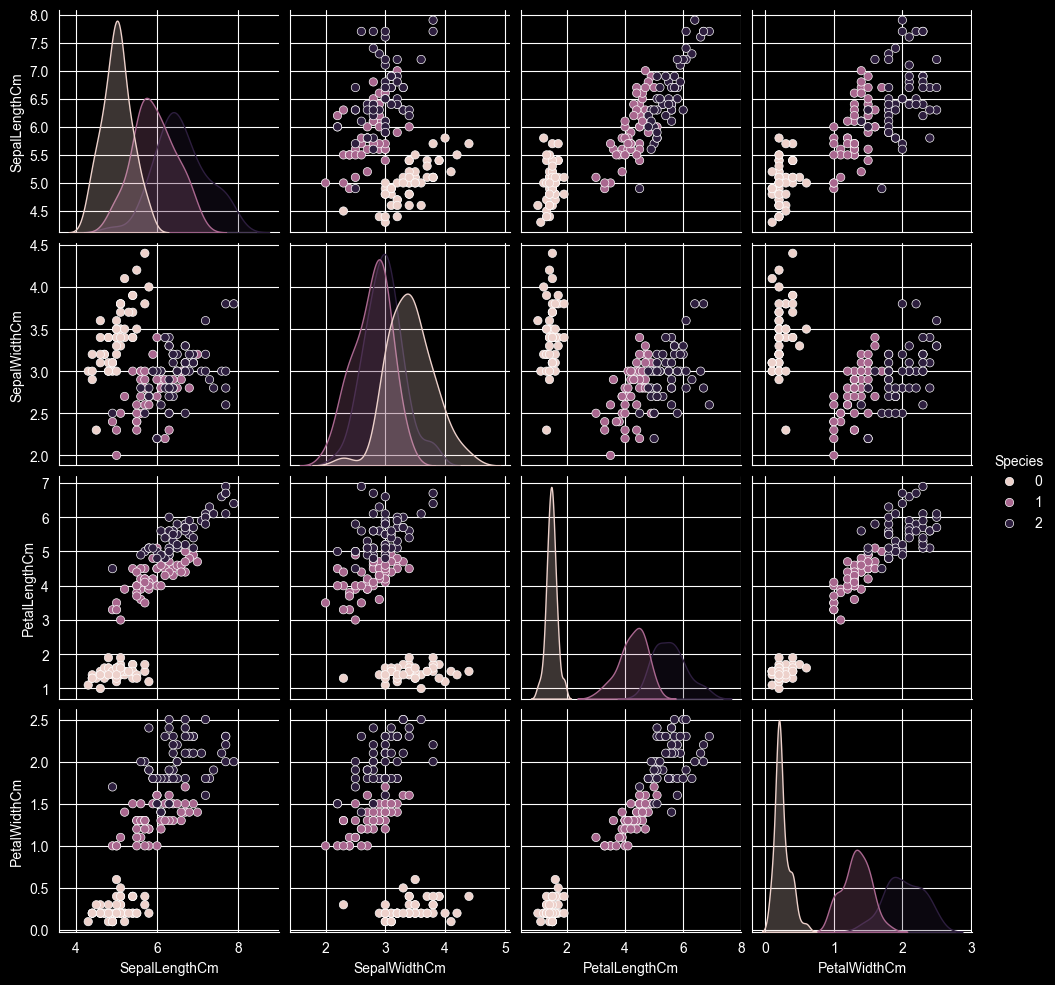

In [67]:
import seaborn as sns
sns.pairplot(df, hue='Species')
plt.show()

In [68]:
new_df = df[df['Species'] != 0][['SepalLengthCm', 'SepalWidthCm', 'Species']]

In [69]:
new_df.head()

,SepalLengthCm,SepalWidthCm,Species
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1
54,6.5,2.8,1


In [70]:
new_df.shape

(100, 3)

In [71]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [73]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [74]:
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

In [75]:
for estimator in estimators:
    x = cross_val_score(estimator[1], X, y, cv=10, scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
rf 0.7
knn 0.76


In [76]:
from sklearn.ensemble import VotingClassifier

# Hard Voting

In [77]:
vc = VotingClassifier(estimators=estimators, voting='hard')
x = cross_val_score(vc, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


# Soft Voting

In [78]:
vc1 = VotingClassifier(estimators=estimators, voting='soft')
x = cross_val_score(vc1, X, y, cv=10, scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


# Weighted Voting

In [79]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators, voting='soft', weights=[i,j,k])
            x = cross_val_score(vc, X, y, cv=10, scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))

for i=1,j=1,k=1 0.77
for i=1,j=1,k=2 0.76
for i=1,j=1,k=3 0.75
for i=1,j=2,k=1 0.75
for i=1,j=2,k=2 0.75
for i=1,j=2,k=3 0.76
for i=1,j=3,k=1 0.75
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.76
for i=2,j=1,k=1 0.77
for i=2,j=1,k=2 0.77
for i=2,j=1,k=3 0.77
for i=2,j=2,k=1 0.77
for i=2,j=2,k=2 0.76
for i=2,j=2,k=3 0.76
for i=2,j=3,k=1 0.75
for i=2,j=3,k=2 0.75
for i=2,j=3,k=3 0.75
for i=3,j=1,k=1 0.81
for i=3,j=1,k=2 0.78
for i=3,j=1,k=3 0.79
for i=3,j=2,k=1 0.76
for i=3,j=2,k=2 0.78
for i=3,j=2,k=3 0.76
for i=3,j=3,k=1 0.75
for i=3,j=3,k=2 0.76
for i=3,j=3,k=3 0.77
